In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Import data

In [2]:
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")

Separate PM from Estimates

In [3]:
ET_OBS = STN_DATA.loc[dict(Product="PM")]
ET_REMOTE = STN_DATA.drop_sel(Product="PM")

In [4]:
ET_REMOTE

<xarray.DataArray 'ET' (Station: 21, Product: 11, datetime: 276)> Size: 510kB
[63756 values with dtype=float64]
Coordinates:
  * Station   (Station) <U2 168B 'AY' 'BE' 'BT' 'CA' ... 'RP' 'SA' 'SI' 'VO'
  * Product   (Product) <U6 264B 'AQUA' 'ERA5' 'GLDAS' ... 'TERRA' 'TH' 'WaPOR'
  * datetime  (datetime) datetime64[ns] 2kB 2018-01-01 2018-01-09 ... 2023-12-27

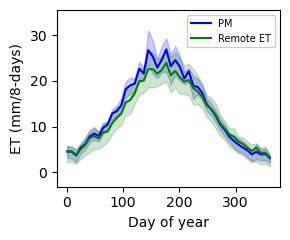

In [13]:
myfig, myax = plt.subplots(figsize=[3,2.5])
ET_OBS.groupby("datetime.dayofyear").mean(dim=["Station", "datetime"]).plot(ax=myax, label="PM", color="blue")
PM_Q25 = ET_OBS.groupby("datetime.dayofyear").quantile(q=0.25, dim=["Station", "datetime"])
PM_Q75 = ET_OBS.groupby("datetime.dayofyear").quantile(q=0.75, dim=["Station", "datetime"])
plt.fill_between(PM_Q25.dayofyear, PM_Q25, PM_Q75, color="blue", alpha=0.2)
ET_REMOTE.groupby("datetime.dayofyear").mean(dim=["Station", "Product", "datetime"]).plot(ax=myax, label="Remote ET", color="green")
ET_R_Q25 = ET_REMOTE.groupby("datetime.dayofyear").quantile(q=0.25, dim=["Station", "Product", "datetime"])
ET_R_Q75 = ET_REMOTE.groupby("datetime.dayofyear").quantile(q=0.75, dim=["Station", "Product", "datetime"])
plt.fill_between(ET_R_Q25.dayofyear, ET_R_Q25, ET_R_Q75, color="green", alpha=0.2)

myax.set_ylabel("ET (mm/8-days)")
myax.set_title("")
myax.set_xlabel("Day of year")

myax.margins(y=0.15)
myax.legend(loc="upper right", fontsize=7, frameon=True, framealpha=1)

# myax.legend()
plt.tight_layout()
plt.savefig("ET4I_ETdoy.png")